Data loaded successfully! Here is a peek at the raw format:


,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,209322,209340,209358,209362,209369,209390,209406,209436,209451,209451
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,334391,334408,334408,334427,334427,334427,334427,334427,334443,334457
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,271441,271448,271463,271469,271469,271477,271477,271490,271494,271496
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,47866,47875,47875,47875,47875,47875,47875,47875,47890,47890
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,105255,105277,105277,105277,105277,105277,105277,105277,105288,105288



Data cleaned and reshaped for time-series analysis!


/tmp/ipykernel_6895/2352253330.py:26: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  time_series_data.index = pd.to_datetime(time_series_data.index)


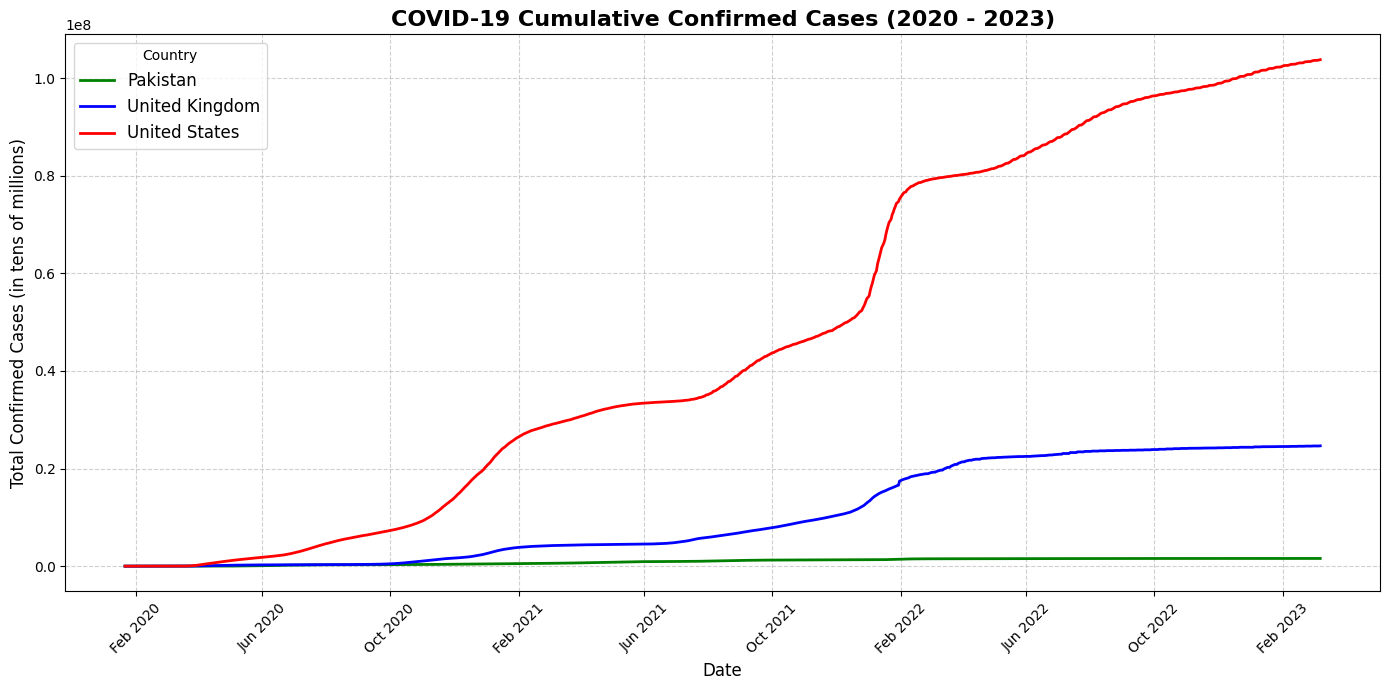

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

url = 'https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv'
covid_data = pd.read_csv(url)

print("Data loaded successfully! Here is a peek at the raw format:")
display(covid_data.head())

covid_clean = covid_data.drop(columns=['Province/State', 'Lat', 'Long'])

# 2. Group by Country (some countries have their data split by province, we want the total)
covid_grouped = covid_clean.groupby('Country/Region').sum()

# 3. Filter for the 3 specific countries we want to compare
countries_to_compare = ['Pakistan', 'United Kingdom', 'US']
covid_filtered = covid_grouped.loc[countries_to_compare]

# Right now, dates are columns. For a time-series, dates need to be the rows (the index).
# The .T command flips the dataframe on its side.
time_series_data = covid_filtered.T

# 5. Convert the index from text into actual DateTime objects so the computer understands time
time_series_data.index = pd.to_datetime(time_series_data.index)

print("\nData cleaned and reshaped for time-series analysis!")

plt.figure(figsize=(14, 7))

# Draw a line for each country
sns.lineplot(data=time_series_data, x=time_series_data.index, y='Pakistan', label='Pakistan', linewidth=2, color='green')
sns.lineplot(data=time_series_data, x=time_series_data.index, y='United Kingdom', label='United Kingdom', linewidth=2, color='blue')
sns.lineplot(data=time_series_data, x=time_series_data.index, y='US', label='United States', linewidth=2, color='red')

plt.title('COVID-19 Cumulative Confirmed Cases (2020 - 2023)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Confirmed Cases (in tens of millions)', fontsize=12)

#  dates on the bottom (showing only the Month and Year)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Country', fontsize=12)

plt.tight_layout()
plt.show()

TASK 3: COVID-19 Global Trends Analysis

Dataset Chosen: Johns Hopkins University (JHU) COVID-19 Time Series (Confirmed Global Cases)

For this project, I used the publicly available COVID-19 dataset maintained by Johns Hopkins University. Instead of just looking at static totals, the goal was to analyze trends over time. From the available metrics (cases, recoveries, vaccinations), I specifically focused on tracking the daily confirmed cases to see the true historical footprint of the virus from January 2020 through early 2023.

1. Building Time-Series Visualizations and Comparing Multiple Countries

Plotting the entire world on one chart would be incredibly messy and hard to read. To solve this, I built clear time-series visualizations and filtered the dataset to compare multiple countries. I selected the United States, the United Kingdom, and Pakistan. This allowed me to compare regions with vastly different population sizes, geographical locations, and healthcare infrastructures to see how their experiences differed.

2. Identifying Patterns, Peaks, and Anomalies

By looking at the plotted time-series data, several distinct stories emerged:

The US : The United States displayed the most aggressive growth curve. We can easily identify massive peaks during the winter months, culminating in a gigantic, explosive spike in late 2021 and early 2022. This massive jump is a clear deviation compared to the earlier months and perfectly aligns with the spread of the highly contagious Omicron variant.

The UK : The UK showed a very unique pattern. Instead of a smooth, continuous curve, its graph looks like a staircase. We see long periods of flat, slow growth that are suddenly interrupted by sharp, nearly vertical jumps. These sudden structural deviations represent rapid new variant outbreaks before the curve flattens out again.

Pakistan : When compared side-by-side with the Western nations, Pakistan’s data revealed a remarkably flat and stable pattern. It maintained a slow, controlled, and steady linear growth rate throughout the timeline, entirely avoiding the severe, explosive peaks seen in the US or UK.

Conclusion:
The most important narrative to draw from this analysis is that the pandemic's timeline was not universal. The visualizations clearly prove that while countries like the US and UK suffered through explosive surges that drastically multiplied their total cases in just weeks, Pakistan's trajectory remained relatively calm and steady. By analyzing time-series data, we can see exactly when and where the worst waves hit across the globe.